# code to generate panels of schematic figure (Figure _?_)

### imports

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from os.path import join as opj
from itertools import zip_longest
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

### paths

In [2]:
data_dir = '../../data'
ep_data_dir = opj(data_dir, 'models', 'episodes')
rec_data_dir = opj(data_dir, 'models', 'recalls')
ep_traj_dir = opj(ep_data_dir, 'trajectories')
ep_events_dir = opj(ep_data_dir, 'events')
ep_eventseg_dir = opj(ep_data_dir, 'eventseg-models')
rec_traj_dir = opj(rec_data_dir, 'trajectories')
rec_events_dir = opj(rec_data_dir, 'events')
rec_eventseg_dir = opj(rec_data_dir, 'eventseg-models')
pickle_dir = f'{data_dir}/pickles'

### load data

In [3]:
# Atlanta episode 1 trajectory, events, eventseg model
atlep1_traj = np.load(opj(ep_traj_dir, 'atlep1_trajectory.npy'))
atlep1_events = np.load(opj(ep_events_dir, 'atlep1_events.npy'))
with open(opj(ep_eventseg_dir, 'atlep1_eventseg_model.p'), 'rb') as f:
    atlep1_eventseg = pickle.load(f)

# example participant's data
P8_id = 'debug3dOrm:debugAjPUS'
P8_rec_traj = np.load(opj(rec_traj_dir, 'atlep1', f'{P8_id}.npy'))
P8_rec_events = np.load(opj(rec_events_dir, 'atlep1', f'{P8_id}.npy'))
with open(opj(rec_eventseg_dir, 'atlep1', f'{P8_id}.p'), 'rb') as f:
    P8_rec_eventseg = pickle.load(f)

# average Atlanta episode 1 (immediate) recall events
avg_recall_events = np.load(opj(rec_events_dir, 'atlep1', 'avg_events.npy'))


# across-session ID mapppings
with open(opj(pickle_dir, 'id_maps.p'), 'rb') as f:
    id_maps = pickle.load(f)

### functions

In [4]:
def draw_bounds(ax, eventseg_model, linewidth=1.5):
    """
    Draw event boundaries on a temporal correlation matrix heatmap 
    based on based on a fit brainiak.eventseg.event.EventSegment model
    """
    segments = eventseg_model.segments_[0]   
    bounds = np.where(np.diff(np.argmax(segments, axis=1)))[0]
    bounds_aug = np.concatenate(([0],bounds,[segments.shape[0]]))
    for i in range(len(bounds_aug)-1):
        rect = patches.Rectangle((bounds_aug[i], bounds_aug[i]), bounds_aug[i+1]-bounds_aug[i], 
                                 bounds_aug[i+1]-bounds_aug[i], linewidth=linewidth, edgecolor='#FFF9AE', 
                                 facecolor='none')
        ax.add_patch(rect)
    return ax

# plot panels for figure

In [5]:
# plot params
cmap = plt.cm.bone_r
sns.set_context('talk')

### Atlanta episode 1 topic proportions matrix

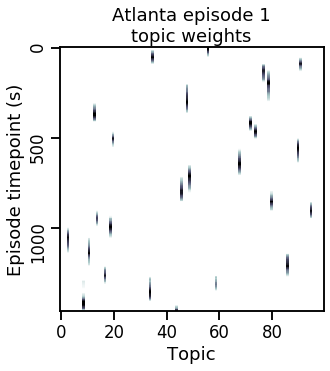

In [6]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5.5, 5.5)
data = pd.DataFrame(atlep1_traj)
sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('Atlanta episode 1\ntopic weights')
ax.set_xlabel('Topic')
ax.set_ylabel('Episode timepoint (s)')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.collections[0].remove()
aspect_ratio = atlep1_traj.shape[1] / atlep1_traj.shape[0]
ax.imshow(atlep1_traj, aspect=aspect_ratio, cmap=cmap)
plt.tight_layout()
plt.show()

### Atlanta episode 1 temporal correlation matrix

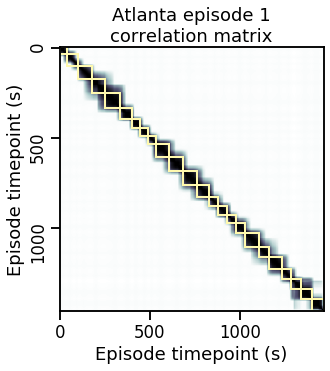

In [7]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5.5, 5.5)
data = pd.DataFrame(atlep1_traj).T.corr()
sns.heatmap(data, cmap=cmap, xticklabels=500, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title(f'Atlanta episode 1\ncorrelation matrix')
ax.set_xlabel('Episode timepoint (s)')
ax.set_ylabel('Episode timepoint (s)')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax = draw_bounds(ax, atlep1_eventseg, linewidth=2)
ax.collections[0].remove()
ax.imshow(data, aspect='equal', cmap=cmap)
plt.tight_layout()
plt.show()

### Atlanta episode 1 events

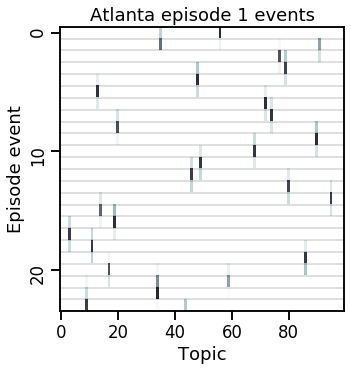

In [8]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)
data = pd.DataFrame(atlep1_events)
sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=10, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('Atlanta episode 1 events')
ax.set_ylabel('Episode event')
ax.set_xlabel('Topic')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.hlines(list(range(atlep1_events.shape[0])), *ax.get_xlim(), linewidth=0.25)
ax.set_aspect(atlep1_events.shape[1] / atlep1_events.shape[0])
plt.tight_layout()
plt.show()

### P8 recall topic proportions matrix

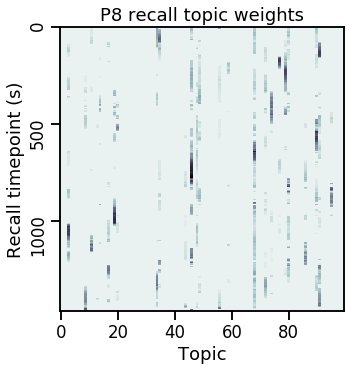

In [9]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)
data = pd.DataFrame(P8_rec_traj)
sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('P8 recall topic weights')
ax.set_ylabel('Recall timepoint (s)')
ax.set_xlabel('Topic')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.collections[0].remove()
aspect_ratio = data.shape[1] / data.shape[0]
ax.imshow(data, aspect=aspect_ratio, cmap=cmap)
plt.tight_layout()
plt.show()

### P8 recall temporal correlation matrix

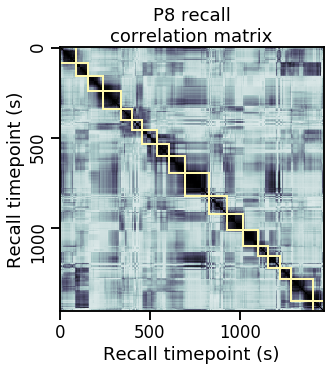

In [10]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)

data = pd.DataFrame(P8_rec_traj).T.corr()
sns.heatmap(data, cmap=cmap, xticklabels=500, yticklabels=500, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('P8 recall\ncorrelation matrix')
ax.set_ylabel('Recall timepoint (s)')
ax.set_xlabel('Recall timepoint (s)')

for _, spine in ax.spines.items():
    spine.set_visible(True)
    
ax = draw_bounds(ax, P8_rec_eventseg, linewidth=2)
ax.collections[0].remove()
ax.imshow(data, aspect='equal', cmap=cmap)
plt.tight_layout()
plt.show()

### P8 recall events

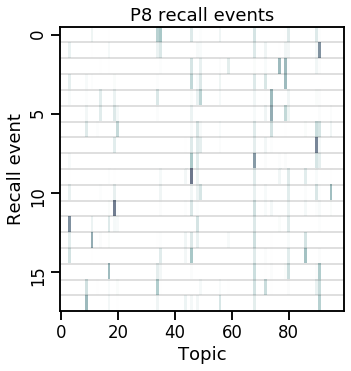

In [11]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)    

data = pd.DataFrame(P8_rec_events)
ax = sns.heatmap(data, cmap=cmap, xticklabels=20, yticklabels=5, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_title('P8 recall events')
ax.set_ylabel('Recall event')
ax.set_xlabel('Topic')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.set_aspect(P8_rec_events.shape[1] / P8_rec_events.shape[0])
ax.hlines(list(range(P8_rec_events.shape[0])), *ax.get_xlim(), linewidth=0.25)
plt.tight_layout()
plt.show()

### Atlanta episode 1-P8 recall event match matrix

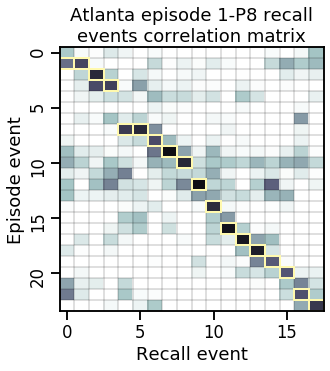

In [12]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)

data = pd.DataFrame(1-cdist(atlep1_events, P8_rec_events, 'correlation'))
sns.heatmap(data, cmap=cmap, xticklabels=5, yticklabels=5, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_xlabel('Recall event')
ax.set_ylabel('Episode event')
ax.set_title('Atlanta episode 1-P8 recall\nevents correlation matrix')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.hlines(list(range(data.shape[0])), *ax.get_xlim(), linewidth=.25)
ax.vlines(list(range(data.shape[1])), *ax.get_ylim(), linewidth=.25)

bounds = np.argmax(data.values, axis=0)
for i, b in enumerate(bounds):
    rect = patches.Rectangle((i, b), 1, 1, linewidth=2, edgecolor='#FFF9AE', facecolor='none', zorder=2)
    ax.add_patch(rect)
    
aspect_ratio = P8_rec_events.shape[0] / atlep1_events.shape[0]
ax.imshow(data, aspect=aspect_ratio, cmap=cmap)
plt.tight_layout()
plt.show()

### Average Atlanta episode 1-recall events match matrix

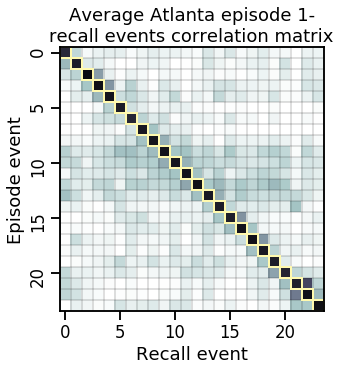

In [13]:
fig, ax = plt.subplots(1,1)
fig.set_size_inches(5.5, 5.5)

data = pd.DataFrame(1-cdist(atlep1_events, avg_recall_events, 'correlation'))
sns.heatmap(data, cmap=cmap, xticklabels=5, yticklabels=5, vmin=0, vmax=1, cbar=False, ax=ax)
ax.set_xlabel('Recall event')
ax.set_ylabel('Episode event')
ax.set_title('Average Atlanta episode 1-\nrecall events correlation matrix')

for _, spine in ax.spines.items():
    spine.set_visible(True)

ax.hlines(list(range(data.shape[0])), *ax.get_xlim(), linewidth=.25)
ax.vlines(list(range(data.shape[1])), *ax.get_ylim(), linewidth=.25)

bounds = np.argmax(data.values, axis=0)
for i, b in enumerate(bounds):
    rect = patches.Rectangle((i, b), 1, 1, linewidth=2, edgecolor='#FFF9AE', facecolor='none', zorder=2)
    ax.add_patch(rect)

ax.imshow(data, aspect='equal', cmap=cmap)
plt.tight_layout()
plt.show()